In [1]:
import sys
sys.path.append("../")

from smcdet.sampler import SMCsampler
from smcdet.prior import M71Prior
from smcdet.images import M71ImageModel
from smcdet.kernel import SingleComponentMH
from smcdet.checkerboard import CheckerboardSMC

import torch

import matplotlib.pyplot as plt

import pickle

from einops import rearrange

from utils.misc import select_cuda_device

device = select_cuda_device(min_free_mb=100)
torch.cuda.set_device(device)
torch.set_default_device(device)

Selected device 0, which has 10822 MB available.


In [2]:
with open('../experiments/deprecated/m71/data/params.pkl', 'rb') as f:
    params = pickle.load(f)

## Ground truth: 8x8 image with four 4x4 tiles

We create a noiseless 8×8-pixel image with 4 stars, one per tile, placed close to the tile
intersection at pixel (4, 4). This tests how CheckerboardSMC handles conditioning when sources
near tile boundaries contribute PSF light to neighboring tiles.

The checkerboard pattern for a 2×2 grid assigns each tile a different color:
```
0 3
1 2
```
So all 4 tiles are processed sequentially, each conditioned on previously-sampled tiles.

Image shape: torch.Size([8, 8])
True stars: 4
True locs:
tensor([[2.5000, 2.5000],
        [2.5000, 5.5000],
        [5.5000, 2.5000],
        [5.5000, 5.5000]], device='cuda:0')
True fluxes: tensor([10., 15., 20., 25.], device='cuda:0')


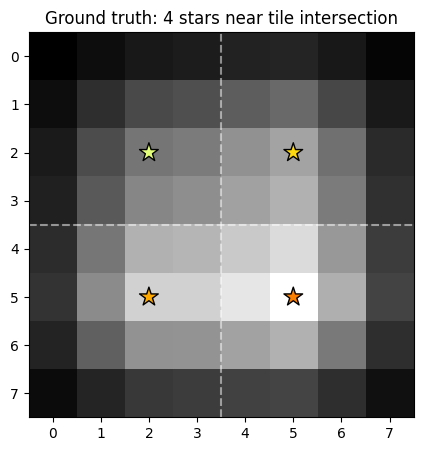

In [3]:
torch.manual_seed(0)

image_dim = 8
tile_dim = 4
pad = 4
image_pad = 4

background = params["background"]
adu_per_nmgy = params["adu_per_nmgy"]
psf_params = params["psf_params"]
psf_radius = params["psf_radius"]
noise_additive = params["noise_additive"]
noise_multiplicative = params["noise_multiplicative"]

# 4 stars near the tile intersection at (4, 4)
true_locs = torch.tensor([
    [2.5, 2.5],  # tile (0,0)
    [2.5, 5.5],  # tile (0,1)
    [5.5, 2.5],  # tile (1,0)
    [5.5, 5.5],  # tile (1,1)
])
true_fluxes = torch.tensor([10.0, 15.0, 20.0, 25.0])

# Render noiseless image
TrueImageModel = M71ImageModel(
    h_lower=0, h_upper=image_dim,
    w_lower=0, w_upper=image_dim,
    background=background,
    adu_per_nmgy=adu_per_nmgy,
    psf_params=psf_params,
    psf_radius=psf_radius,
    noise_additive=noise_additive,
    noise_multiplicative=noise_multiplicative,
)

locs_5d = true_locs.unsqueeze(0).unsqueeze(0).unsqueeze(0)  # [1, 1, 1, 4, 2]
fluxes_4d = true_fluxes.unsqueeze(0).unsqueeze(0).unsqueeze(0)  # [1, 1, 1, 4]

psf = TrueImageModel.psf(locs_5d)
rate = (
    psf * rearrange(adu_per_nmgy * fluxes_4d, "numH numW n d -> numH numW 1 1 n d")
).sum(-1) + background
image = rate.squeeze()  # [8, 8]

print(f"Image shape: {image.shape}")
print(f"True stars: {len(true_fluxes)}")
print(f"True locs:\n{true_locs}")
print(f"True fluxes: {true_fluxes}")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
_ = ax.imshow(image.cpu(), cmap='gray')
_ = ax.scatter(
    true_locs[:, 1].cpu() - 0.5,
    true_locs[:, 0].cpu() - 0.5,
    c=true_fluxes.cpu(),
    vmin=10,
    vmax=25,
    cmap='Wistia', marker='*', edgecolors='black', s=200,
)
_ = ax.axhline(y=tile_dim - 0.5, color='white', linestyle='--', alpha=0.5)
_ = ax.axvline(x=tile_dim - 0.5, color='white', linestyle='--', alpha=0.5)
_ = ax.set_title('Ground truth: 4 stars near tile intersection')

## Run CheckerboardSMC

In [4]:
max_objects = 4

prior_kwargs = dict(
    num_objects=max_objects,
    counts_rate=params['counts_rate'],
    h_lower=0, h_upper=tile_dim,  # overridden by CheckerboardSMC
    w_lower=0, w_upper=tile_dim,
    flux_alpha=params['flux_alpha'],
    flux_lower=params['flux_lower'],
    flux_upper=params['flux_upper'],
)

image_model_kwargs = dict(
    background=background,
    adu_per_nmgy=adu_per_nmgy,
    psf_params=psf_params,
    psf_radius=psf_radius,
    noise_additive=noise_additive,
    noise_multiplicative=noise_multiplicative,
)

kernel_kwargs = dict(
    num_iters=100,
    locs_stdev=0.1,
    fluxes_stdev=2.5,
    fluxes_min=params['flux_lower'],
    fluxes_max=params['flux_upper'],
)

cb = CheckerboardSMC(
    image=image,
    tile_dim=tile_dim,
    pad=pad,
    image_pad=image_pad,
    PriorClass=M71Prior,
    prior_kwargs=prior_kwargs,
    ImageModelClass=M71ImageModel,
    image_model_kwargs=image_model_kwargs,
    MutationKernelClass=SingleComponentMH,
    kernel_kwargs=kernel_kwargs,
    num_catalogs=2500,
    ess_threshold_prop=0.5,
    resample_method='multinomial',
    max_smc_iters=100,
    prune_flux_lower=params['flux_detection_threshold'],
    print_every=5,
)

cb.run()

Color 0: 1 tile(s) (1x1 sub-grid)
  Tile (0, 0) -> sub-grid (0, 0): prior [-4, 8] x [-4, 8], image [-4, 8] x [-4, 8]
starting...
iteration 5: temperature in [0.01, 0.01], acceptance rate in [0.52, 0.52]
iteration 10: temperature in [0.04, 0.04], acceptance rate in [0.63, 0.63]
iteration 15: temperature in [0.16, 0.16], acceptance rate in [0.51, 0.51]
done!

Color 1: 1 tile(s) (1x1 sub-grid)
  Tile (1, 0) -> sub-grid (0, 0): prior [0, 12] x [-4, 8], image [0, 12] x [-4, 8], cond sources: 4
starting...
iteration 5: temperature in [0.01, 0.01], acceptance rate in [0.5, 0.5]
iteration 10: temperature in [0.05, 0.05], acceptance rate in [0.72, 0.72]
iteration 15: temperature in [0.44, 0.44], acceptance rate in [0.34, 0.34]
done!

Color 2: 1 tile(s) (1x1 sub-grid)
  Tile (1, 1) -> sub-grid (0, 0): prior [0, 12] x [0, 12], image [0, 12] x [0, 12], cond sources: 8
starting...
iteration 5: temperature in [0.01, 0.01], acceptance rate in [0.49, 0.49]
iteration 10: temperature in [0.13, 0.13], ac

Posterior count distribution:
  4 stars: 0.526
  5 stars: 0.445
  6 stars: 0.027
  7 stars: 0.002


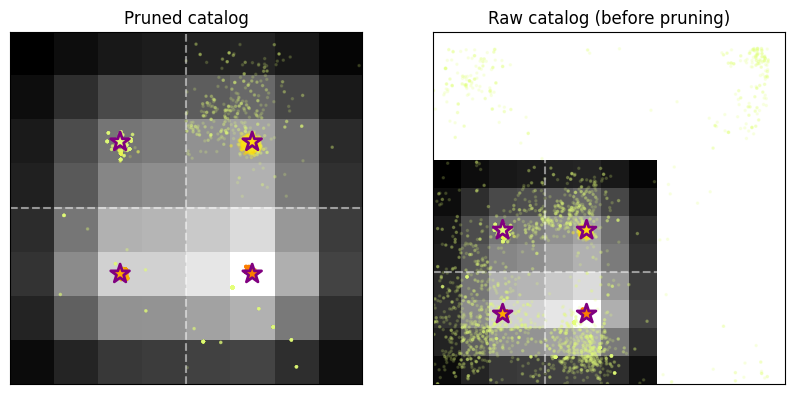

In [5]:
cb_locs = cb.combined_locs.squeeze()
cb_fluxes = cb.combined_fluxes.squeeze()

mask_cb = (cb_fluxes > params['flux_detection_threshold']) \
    & (cb_locs[..., 0] > 0) & (cb_locs[..., 0] < image_dim) \
    & (cb_locs[..., 1] > 0) & (cb_locs[..., 1] < image_dim)

cb_counts = mask_cb.sum(-1)

print(f"Posterior count distribution:")
vals, cnts = cb_counts.unique(return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  {v.int().item()} stars: {c.item() / cb.num_catalogs:.3f}")

# Raw catalog (before pruning)
raw_locs = cb.combined_raw_locs.squeeze()
raw_fluxes = cb.combined_raw_fluxes.squeeze()
mask_raw = raw_fluxes > params['flux_detection_threshold']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: pruned catalog
idx = torch.arange(cb.num_catalogs)
axes[0].imshow(image.cpu(), cmap='gray')
axes[0].scatter(
    cb_locs[idx][mask_cb[idx], 1].cpu() - 0.5,
    cb_locs[idx][mask_cb[idx], 0].cpu() - 0.5,
    c=cb_fluxes[idx][mask_cb[idx]].cpu(),
    vmin=10, vmax=25,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[0].set_title('Pruned catalog')

# Right: raw catalog
axes[1].imshow(image.cpu(), cmap='gray')
axes[1].scatter(
    raw_locs[idx][mask_raw[idx], 1].cpu() - 0.5,
    raw_locs[idx][mask_raw[idx], 0].cpu() - 0.5,
    c=raw_fluxes[idx][mask_raw[idx]].cpu(),
    vmin=10, vmax=25,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[1].set_title('Raw catalog (before pruning)')

for ax in axes:
    ax.scatter(
        true_locs[:, 1].cpu() - 0.5,
        true_locs[:, 0].cpu() - 0.5,
        c=true_fluxes.cpu(),
        marker='*', cmap='Wistia', edgecolors='purple', linewidth=2, s=200, zorder=5,
        vmin=10, vmax=25,
    )
    ax.axhline(y=tile_dim - 0.5, color='white', linestyle='--', alpha=0.5)
    ax.axvline(x=tile_dim - 0.5, color='white', linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

## Ground truth: 16x16 image with sixteen 4x4 tiles

Now we demonstrate parallel tile processing with a 16×16-pixel image divided into a 4×4 grid of 4×4 tiles. The checkerboard coloring assigns 4 tiles to each of the 4 colors, forming a 2×2 sub-grid per color — so all 4 tiles of the same color are processed **simultaneously**.

We place 16 stars (one per tile), each near the center of its tile (within 0.25 px), to provide a clean baseline for the checkerboard method.

Image shape: torch.Size([16, 16])
True stars: 9
True locs:
tensor([[ 4.1000,  2.3000],
        [ 3.8000,  9.7000],
        [ 8.2000,  5.5000],
        [ 7.9000, 13.1000],
        [12.1000,  1.8000],
        [11.8000, 10.4000],
        [ 2.5000,  4.2000],
        [ 9.3000,  7.9000],
        [ 6.1000, 12.1000]], device='cuda:0')
True fluxes: tensor([20.5000, 19.2000, 21.3000, 18.7000, 20.1000, 19.8000, 21.0000, 18.5000,
        20.4000], device='cuda:0')


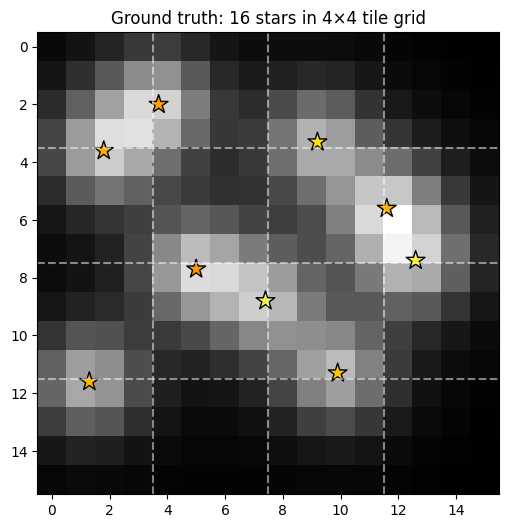

In [6]:
torch.manual_seed(0)

image_dim_large = 16
tile_dim_large = 4

true_locs_large = torch.tensor([                                                                                                                           
    # On horizontal boundaries (h ≈ 4, 8, 12)
    [4.1, 2.3],   # h=4 boundary                                                                                                                           
    [3.8, 9.7],   # h=4 boundary                                                                                                                         
    [8.2, 5.5],   # h=8 boundary
    [7.9, 13.1],  # h=8 boundary
    [12.1, 1.8],  # h=12 boundary
    [11.8, 10.4], # h=12 boundary
    # On vertical boundaries (w ≈ 4, 8, 12)
    [2.5, 4.2],   # w=4 boundary
    [9.3, 7.9],   # w=8 boundary
    [6.1, 12.1],  # w=12 boundary, also near h=4+2
])
true_fluxes_large = torch.tensor([
    20.5, 19.2, 21.3, 18.7, 20.1, 19.8,
    21.0, 18.5, 20.4,
])

# Render noiseless image
TrueImageModelLarge = M71ImageModel(
    h_lower=0, h_upper=image_dim_large,
    w_lower=0, w_upper=image_dim_large,
    background=background,
    adu_per_nmgy=adu_per_nmgy,
    psf_params=psf_params,
    psf_radius=psf_radius,
    noise_additive=noise_additive,
    noise_multiplicative=noise_multiplicative,
)

locs_5d_large = true_locs_large.unsqueeze(0).unsqueeze(0).unsqueeze(0)
fluxes_4d_large = true_fluxes_large.unsqueeze(0).unsqueeze(0).unsqueeze(0)

psf_large = TrueImageModelLarge.psf(locs_5d_large)
rate_large = (
    psf_large * rearrange(adu_per_nmgy * fluxes_4d_large, "numH numW n d -> numH numW 1 1 n d")
).sum(-1) + background
image_large = rate_large.squeeze()

print(f"Image shape: {image_large.shape}")
print(f"True stars: {len(true_fluxes_large)}")
print(f"True locs:\n{true_locs_large}")
print(f"True fluxes: {true_fluxes_large}")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
_ = ax.imshow(image_large.cpu(), cmap='gray')
_ = ax.scatter(
    true_locs_large[:, 1].cpu() - 0.5,
    true_locs_large[:, 0].cpu() - 0.5,
    vmin=18, vmax=22,
    c=true_fluxes_large.cpu(), cmap='Wistia', marker='*', edgecolors='black', s=200,
)
for boundary in [3.5, 7.5, 11.5]:
    _ = ax.axhline(y=boundary, color='white', linestyle='--', alpha=0.5)
    _ = ax.axvline(x=boundary, color='white', linestyle='--', alpha=0.5)
_ = ax.set_title('Ground truth: 16 stars in 4×4 tile grid')

In [7]:
cb_large = CheckerboardSMC(
    image=image_large,
    tile_dim=tile_dim_large,
    pad=pad,
    image_pad=image_pad,
    PriorClass=M71Prior,
    prior_kwargs=prior_kwargs,
    ImageModelClass=M71ImageModel,
    image_model_kwargs=image_model_kwargs,
    MutationKernelClass=SingleComponentMH,
    kernel_kwargs=kernel_kwargs,
    num_catalogs=2500,
    ess_threshold_prop=0.5,
    resample_method='multinomial',
    max_smc_iters=100,
    prune_flux_lower=params['flux_detection_threshold'],
    print_every=5,
)

cb_large.run()

Color 0: 4 tile(s) (2x2 sub-grid)
  Tile (0, 0) -> sub-grid (0, 0): prior [-4, 8] x [-4, 8], image [-4, 8] x [-4, 8]
  Tile (0, 2) -> sub-grid (0, 1): prior [-4, 8] x [4, 16], image [-4, 8] x [4, 16]
  Tile (2, 0) -> sub-grid (1, 0): prior [4, 16] x [-4, 8], image [4, 16] x [-4, 8]
  Tile (2, 2) -> sub-grid (1, 1): prior [4, 16] x [4, 16], image [4, 16] x [4, 16]
starting...
iteration 5: temperature in [0.0, 0.0], acceptance rate in [0.54, 0.75]
iteration 10: temperature in [0.01, 0.04], acceptance rate in [0.48, 0.83]
iteration 15: temperature in [0.08, 0.23], acceptance rate in [0.43, 0.65]
iteration 20: temperature in [0.59, 1.0], acceptance rate in [0.15, 0.32]
done!

Color 1: 4 tile(s) (2x2 sub-grid)
  Tile (1, 0) -> sub-grid (0, 0): prior [0, 12] x [-4, 8], image [0, 12] x [-4, 8], cond sources: 8
  Tile (1, 2) -> sub-grid (0, 1): prior [0, 12] x [4, 16], image [0, 12] x [4, 16], cond sources: 8
  Tile (3, 0) -> sub-grid (1, 0): prior [8, 20] x [-4, 8], image [8, 20] x [-4, 8], c

Posterior count distribution:
  8 stars: 0.714
  9 stars: 0.260
  10 stars: 0.025
  11 stars: 0.001


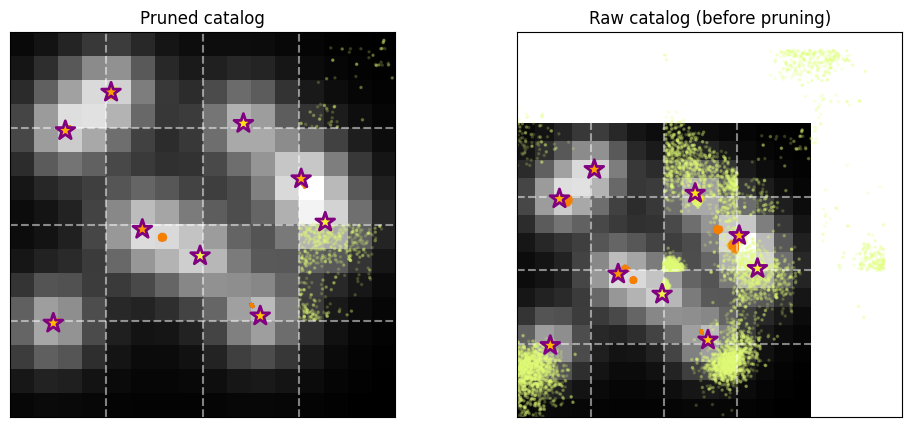

In [8]:
cb_large_locs = cb_large.combined_locs.squeeze()
cb_large_fluxes = cb_large.combined_fluxes.squeeze()

mask_large = (cb_large_fluxes > params['flux_detection_threshold']) \
    & (cb_large_locs[..., 0] > 0) & (cb_large_locs[..., 0] < image_dim_large) \
    & (cb_large_locs[..., 1] > 0) & (cb_large_locs[..., 1] < image_dim_large)

cb_large_counts = mask_large.sum(-1)

print(f"Posterior count distribution:")
vals, cnts = cb_large_counts.unique(return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  {v.int().item()} stars: {c.item() / cb_large.num_catalogs:.3f}")

# Raw catalog (before pruning)
raw_large_locs = cb_large.combined_raw_locs.squeeze()
raw_large_fluxes = cb_large.combined_raw_fluxes.squeeze()
mask_raw_large = raw_large_fluxes > params['flux_detection_threshold']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

idx = torch.arange(cb_large.num_catalogs)

# Left: pruned catalog
axes[0].imshow(image_large.cpu(), cmap='gray')
axes[0].scatter(
    cb_large_locs[idx][mask_large[idx], 1].cpu() - 0.5,
    cb_large_locs[idx][mask_large[idx], 0].cpu() - 0.5,
    c=cb_large_fluxes[idx][mask_large[idx]].cpu(),
    vmin=18, vmax=22,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[0].set_title('Pruned catalog')

# Right: raw catalog
axes[1].imshow(image_large.cpu(), cmap='gray')
axes[1].scatter(
    raw_large_locs[idx][mask_raw_large[idx], 1].cpu() - 0.5,
    raw_large_locs[idx][mask_raw_large[idx], 0].cpu() - 0.5,
    c=raw_large_fluxes[idx][mask_raw_large[idx]].cpu(),
    vmin=18, vmax=22,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[1].set_title('Raw catalog (before pruning)')

for ax in axes:
    ax.scatter(
        true_locs_large[:, 1].cpu() - 0.5,
        true_locs_large[:, 0].cpu() - 0.5,
        c=true_fluxes_large.cpu(), vmin=18, vmax=22,
        marker='*', cmap='Wistia', edgecolors='purple', linewidth=2, s=200, zorder=5,
    )
    for boundary in [3.5, 7.5, 11.5]:
        ax.axhline(y=boundary, color='white', linestyle='--', alpha=0.5)
        ax.axvline(x=boundary, color='white', linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

## 16x16 image with noise

Same ground truth as above, but now we sample a noisy image from the M71 noise model
(Gaussian with signal-dependent variance) instead of using the noiseless expected rate.

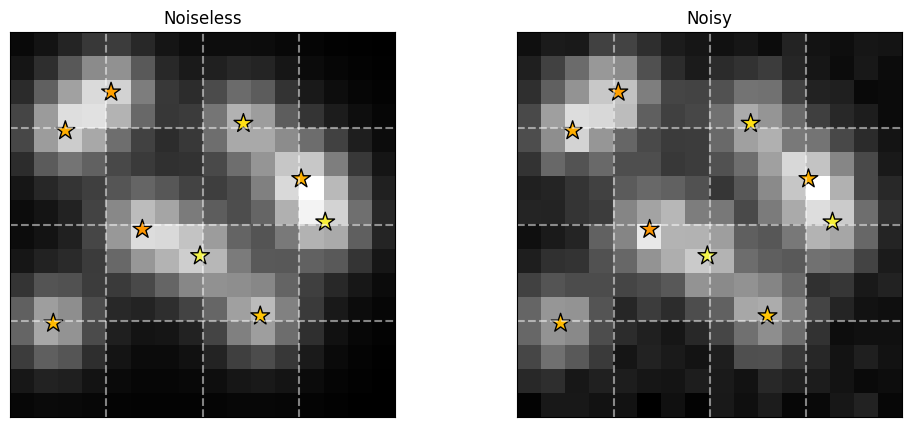

In [9]:
torch.manual_seed(0)

from torch.distributions import Normal as TorchNormal

# Sample noisy image from the noiseless rate
noise_std = (noise_additive + noise_multiplicative * rate_large.squeeze()).sqrt()
image_large_noisy = TorchNormal(rate_large.squeeze(), noise_std).sample()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_large.cpu(), cmap='gray')
axes[0].set_title('Noiseless')
axes[1].imshow(image_large_noisy.cpu(), cmap='gray')
axes[1].set_title('Noisy')
for ax in axes:
    ax.scatter(
        true_locs_large[:, 1].cpu() - 0.5,
        true_locs_large[:, 0].cpu() - 0.5,
        c=true_fluxes_large.cpu(), vmin=18, vmax=22,
        cmap='Wistia', marker='*', edgecolors='black', s=200,
    )
    for boundary in [3.5, 7.5, 11.5]:
        ax.axhline(y=boundary, color='white', linestyle='--', alpha=0.5)
        ax.axvline(x=boundary, color='white', linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

In [10]:
cb_noisy = CheckerboardSMC(
    image=image_large_noisy,
    tile_dim=tile_dim_large,
    pad=pad,
    image_pad=image_pad,
    PriorClass=M71Prior,
    prior_kwargs=prior_kwargs,
    ImageModelClass=M71ImageModel,
    image_model_kwargs=image_model_kwargs,
    MutationKernelClass=SingleComponentMH,
    kernel_kwargs=kernel_kwargs,
    num_catalogs=2500,
    ess_threshold_prop=0.5,
    resample_method='multinomial',
    max_smc_iters=100,
    prune_flux_lower=params['flux_detection_threshold'],
    print_every=5,
)

cb_noisy.run()

Color 0: 4 tile(s) (2x2 sub-grid)
  Tile (0, 0) -> sub-grid (0, 0): prior [-4, 8] x [-4, 8], image [-4, 8] x [-4, 8]
  Tile (0, 2) -> sub-grid (0, 1): prior [-4, 8] x [4, 16], image [-4, 8] x [4, 16]
  Tile (2, 0) -> sub-grid (1, 0): prior [4, 16] x [-4, 8], image [4, 16] x [-4, 8]
  Tile (2, 2) -> sub-grid (1, 1): prior [4, 16] x [4, 16], image [4, 16] x [4, 16]
starting...
iteration 5: temperature in [0.0, 0.0], acceptance rate in [0.56, 0.65]
iteration 10: temperature in [0.01, 0.04], acceptance rate in [0.58, 0.84]
iteration 15: temperature in [0.08, 0.25], acceptance rate in [0.51, 0.68]
iteration 20: temperature in [0.64, 1.0], acceptance rate in [0.18, 0.31]
done!

Color 1: 4 tile(s) (2x2 sub-grid)
  Tile (1, 0) -> sub-grid (0, 0): prior [0, 12] x [-4, 8], image [0, 12] x [-4, 8], cond sources: 8
  Tile (1, 2) -> sub-grid (0, 1): prior [0, 12] x [4, 16], image [0, 12] x [4, 16], cond sources: 8
  Tile (3, 0) -> sub-grid (1, 0): prior [8, 20] x [-4, 8], image [8, 20] x [-4, 8], c

Posterior count distribution (noisy):
  8 stars: 0.310
  9 stars: 0.498
  10 stars: 0.173
  11 stars: 0.019


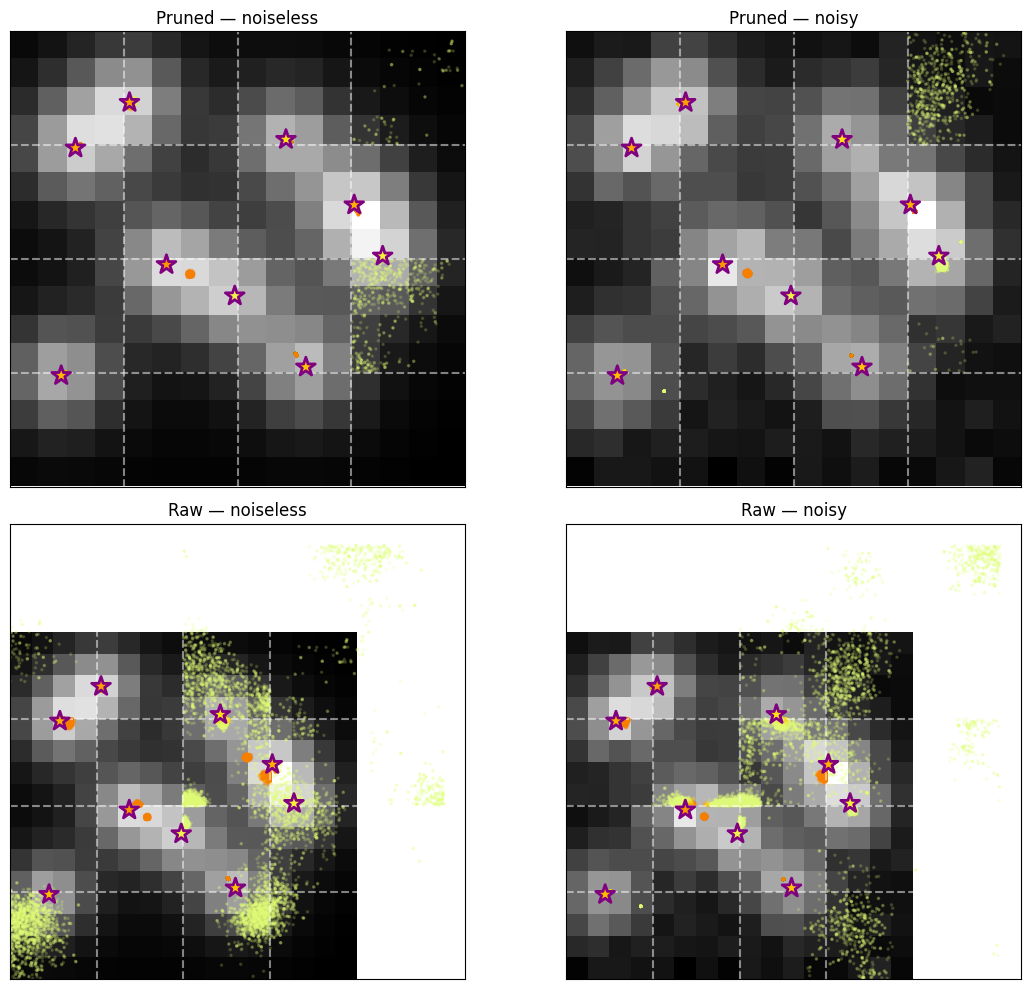

In [14]:
cb_noisy_locs = cb_noisy.combined_locs.squeeze()
cb_noisy_fluxes = cb_noisy.combined_fluxes.squeeze()

mask_noisy = (cb_noisy_fluxes > params['flux_detection_threshold']) \
    & (cb_noisy_locs[..., 0] > 0) & (cb_noisy_locs[..., 0] < image_dim_large) \
    & (cb_noisy_locs[..., 1] > 0) & (cb_noisy_locs[..., 1] < image_dim_large)

cb_noisy_counts = mask_noisy.sum(-1)

print(f"Posterior count distribution (noisy):")
vals, cnts = cb_noisy_counts.unique(return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  {v.int().item()} stars: {c.item() / cb_noisy.num_catalogs:.3f}")

# Raw catalogs (before pruning)
raw_large_locs = cb_large.combined_raw_locs.squeeze()
raw_large_fluxes = cb_large.combined_raw_fluxes.squeeze()
mask_raw_large = raw_large_fluxes > params['flux_detection_threshold']

raw_noisy_locs = cb_noisy.combined_raw_locs.squeeze()
raw_noisy_fluxes = cb_noisy.combined_raw_fluxes.squeeze()
mask_raw_noisy = raw_noisy_fluxes > params['flux_detection_threshold']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

idx = torch.arange(cb_large.num_catalogs)
idx_n = torch.arange(cb_noisy.num_catalogs)

# Top-left: pruned noiseless
axes[0, 0].imshow(image_large.cpu(), cmap='gray')
axes[0, 0].scatter(
    cb_large_locs[idx][mask_large[idx], 1].cpu() - 0.5,
    cb_large_locs[idx][mask_large[idx], 0].cpu() - 0.5,
    c=cb_large_fluxes[idx][mask_large[idx]].cpu(),
    vmin=18, vmax=22,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[0, 0].set_title('Pruned — noiseless')

# Top-right: pruned noisy
axes[0, 1].imshow(image_large_noisy.cpu(), cmap='gray')
axes[0, 1].scatter(
    cb_noisy_locs[idx_n][mask_noisy[idx_n], 1].cpu() - 0.5,
    cb_noisy_locs[idx_n][mask_noisy[idx_n], 0].cpu() - 0.5,
    c=cb_noisy_fluxes[idx_n][mask_noisy[idx_n]].cpu(),
    vmin=18, vmax=22,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[0, 1].set_title('Pruned — noisy')

# Bottom-left: raw noiseless
axes[1, 0].imshow(image_large.cpu(), cmap='gray')
axes[1, 0].scatter(
    raw_large_locs[idx][mask_raw_large[idx], 1].cpu() - 0.5,
    raw_large_locs[idx][mask_raw_large[idx], 0].cpu() - 0.5,
    c=raw_large_fluxes[idx][mask_raw_large[idx]].cpu(),
    vmin=18, vmax=22,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[1, 0].set_title('Raw — noiseless')

# Bottom-right: raw noisy
axes[1, 1].imshow(image_large_noisy.cpu(), cmap='gray')
axes[1, 1].scatter(
    raw_noisy_locs[idx_n][mask_raw_noisy[idx_n], 1].cpu() - 0.5,
    raw_noisy_locs[idx_n][mask_raw_noisy[idx_n], 0].cpu() - 0.5,
    c=raw_noisy_fluxes[idx_n][mask_raw_noisy[idx_n]].cpu(),
    vmin=18, vmax=22,
    marker='.', cmap='Wistia', s=10, alpha=0.15,
)
axes[1, 1].set_title('Raw — noisy')

for ax in axes.flat:
    ax.scatter(
        true_locs_large[:, 1].cpu() - 0.5,
        true_locs_large[:, 0].cpu() - 0.5,
        c=true_fluxes_large.cpu(), vmin=18, vmax=22,
        marker='*', cmap='Wistia', edgecolors='purple', linewidth=2, s=200, zorder=5,
    )
    for boundary in [3.5, 7.5, 11.5]:
        ax.axhline(y=boundary, color='white', linestyle='--', alpha=0.5)
        ax.axvline(x=boundary, color='white', linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()